## Exposure diagnostic

In non-zero-death rows: what is the slope of `log(death_rate) ~ log(exposed)`?

- Slope ≈ 0 → rate is independent of exposure; offset assumption in bulk/tail holds.
- Slope substantially ≠ 0 → exposure directly predicts rate; treating `log(N)` as a free covariate is better than a fixed offset.

We check this unconditionally (no other covariates), and split by bulk vs. tail.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH = "/mnt/team/idd/pub/idd_tc_mortality/00-data/current/input.parquet"

# Threshold quantile used to split bulk vs. tail (matches grid default)
THRESHOLD_QUANTILES = [0.50, 0.75, 0.90]

df = pd.read_parquet(DATA_PATH)
nz = df[df["deaths"] > 0].copy()
nz["death_rate"] = nz["deaths"] / nz["exposed"]
nz["log_rate"] = np.log(nz["death_rate"])
nz["log_exposed"] = np.log(nz["exposed"])

print(f"Total rows: {len(df):,}   Non-zero death rows: {len(nz):,}")

Total rows: 9,186   Non-zero death rows: 445


In [25]:
nosdi_df = df[df['sdi'].isna()]
nosdi_df.head()

,deaths,exposed,wind_speed,sdi,basin,is_island,storm_id,location_id,year,location_name,path_to_top_parent,super_region_name,region_name
50,0,2.764511e+06,25.598989,NaN,WP,1,1980126N08150,53533,1980,Mountain Province,"1,4,9,16,53533","Southeast Asia, East Asia, and Oceania",Southeast Asia
51,0,1.536187e+06,42.851376,NaN,WP,1,1980197N07154,53533,1980,Mountain Province,"1,4,9,16,53533","Southeast Asia, East Asia, and Oceania",Southeast Asia
52,0,1.907496e+06,39.775261,NaN,WP,1,1980201N08155,53533,1980,Mountain Province,"1,4,9,16,53533","Southeast Asia, East Asia, and Oceania",Southeast Asia
53,0,2.761487e+06,43.963444,NaN,WP,1,1980296N05165,53533,1980,Mountain Province,"1,4,9,16,53533","Southeast Asia, East Asia, and Oceania",Southeast Asia
54,0,1.953647e+04,18.679670,NaN,WP,1,1981256N10150,53533,1981,Mountain Province,"1,4,9,16,53533","Southeast Asia, East Asia, and Oceania",Southeast Asia


In [2]:
# --- Overall slope ---
slope, intercept, r, p, se = stats.linregress(nz["log_exposed"], nz["log_rate"])
print(f"Overall  slope={slope:.3f}  r={r:.3f}  p={p:.2e}  n={len(nz)}")

Overall  slope=-0.834  r=-0.710  p=1.51e-69  n=445


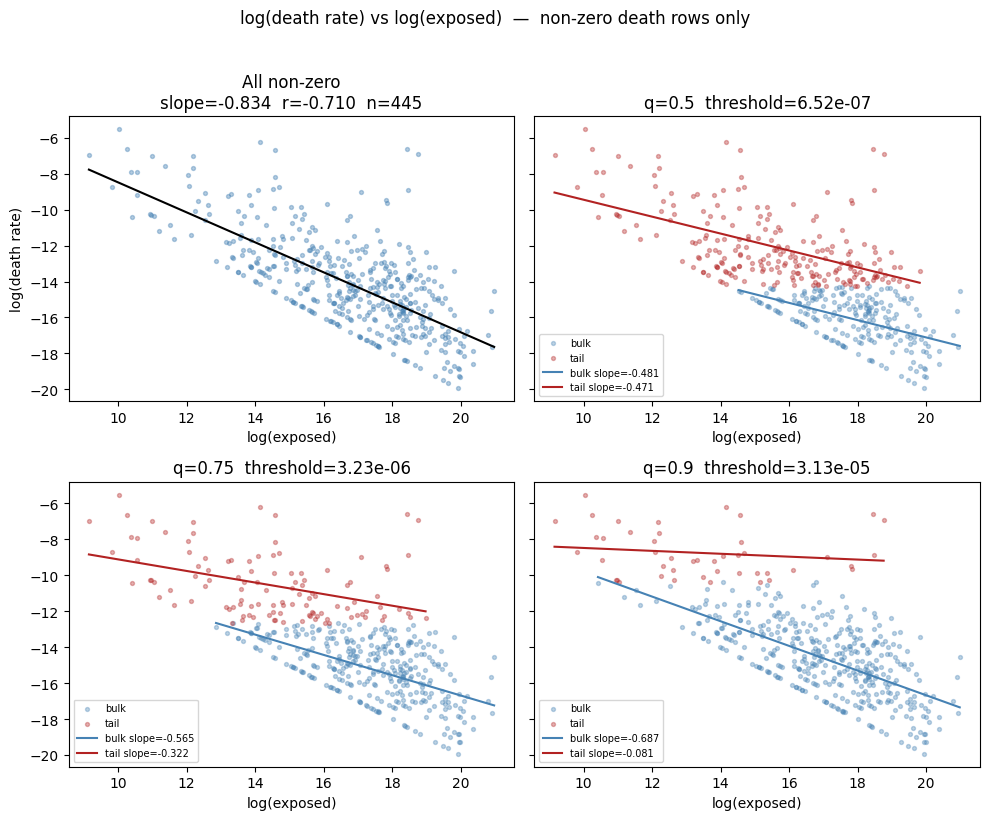

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

def _scatter_with_fit(ax, x, y, title, color):
    ax.scatter(x, y, s=8, alpha=0.4, color=color)
    if len(x) > 2:
        sl, ic, r, p, _ = stats.linregress(x, y)
        xr = np.linspace(x.min(), x.max(), 200)
        ax.plot(xr, ic + sl * xr, color="black", linewidth=1.5)
        ax.set_title(f"{title}\nslope={sl:.3f}  r={r:.3f}  n={len(x):,}")
    else:
        ax.set_title(title)
    ax.set_xlabel("log(exposed)")
    ax.set_ylabel("log(death rate)")

# All non-zero rows
_scatter_with_fit(axes[0], nz["log_exposed"], nz["log_rate"], "All non-zero", "steelblue")

for ax, q in zip(axes[1:], THRESHOLD_QUANTILES):
    threshold = float(np.quantile(nz["death_rate"], q))
    bulk = nz[nz["death_rate"] < threshold]
    tail = nz[nz["death_rate"] >= threshold]

    # Colour-code: bulk=blue, tail=red
    ax.scatter(bulk["log_exposed"], bulk["log_rate"], s=8, alpha=0.35, color="steelblue", label="bulk")
    ax.scatter(tail["log_exposed"], tail["log_rate"], s=8, alpha=0.35, color="firebrick", label="tail")

    if len(bulk) > 2:
        sl_b, ic_b, *_ = stats.linregress(bulk["log_exposed"], bulk["log_rate"] )
        xr = np.linspace(bulk["log_exposed"].min(), bulk["log_exposed"].max(), 200)
        ax.plot(xr, ic_b + sl_b * xr, color="steelblue", linewidth=1.5,
                label=f"bulk slope={sl_b:.3f}")

    if len(tail) > 2:
        sl_t, ic_t, *_ = stats.linregress(tail["log_exposed"], tail["log_rate"] )
        xr = np.linspace(tail["log_exposed"].min(), tail["log_exposed"].max(), 200)
        ax.plot(xr, ic_t + sl_t * xr, color="firebrick", linewidth=1.5,
                label=f"tail slope={sl_t:.3f}")

    ax.set_title(f"q={q}  threshold={threshold:.2e}")
    ax.set_xlabel("log(exposed)")
    ax.legend(fontsize=7)

fig.suptitle("log(death rate) vs log(exposed)  —  non-zero death rows only", y=1.02)
fig.tight_layout()
plt.show()

In [11]:
df

,deaths,exposed,wind_speed,sdi,basin,is_island,storm_id,location_id,year,location_name,path_to_top_parent,super_region_name,region_name,has_deaths,log_exposed
0,0,9.563711e+05,38.104885,0.481786,SP,1,1980001S13173,22,1980,Fiji,"1,4,21,22","Southeast Asia, East Asia, and Oceania",Oceania,0,13.770901
1,18,3.034474e+05,31.793751,0.481786,SP,1,1980081S12170,22,1980,Fiji,"1,4,21,22","Southeast Asia, East Asia, and Oceania",Oceania,1,12.622964
2,0,1.261257e+07,40.924145,0.486503,SP,1,1981011S12185,22,1981,Fiji,"1,4,21,22","Southeast Asia, East Asia, and Oceania",Oceania,0,16.350204
3,0,2.264775e+06,39.380829,0.487139,SP,1,1982024S18166,22,1982,Fiji,"1,4,21,22","Southeast Asia, East Asia, and Oceania",Oceania,0,14.632986
4,9,1.855014e+07,62.537865,0.487371,SP,1,1983054S15179,22,1983,Fiji,"1,4,21,22","Southeast Asia, East Asia, and Oceania",Oceania,1,16.735988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9181,7,1.387604e+07,42.877911,0.449176,NI,0,2023292N11063,157,2023,Yemen,"1,137,138,157",North Africa and Middle East,North Africa and Middle East,1,16.445674
9182,0,9.264920e+05,27.895597,0.683377,WP,0,2017354N08134,13,2017,Malaysia,"1,4,9,13","Southeast Asia, East Asia, and Oceania",Southeast Asia,0,13.739161
9183,0,1.040896e+05,33.445004,NaN,WP,1,2017354N08134,53609,2017,Tawi-Tawi,"1,4,9,16,53609","Southeast Asia, East Asia, and Oceania",Southeast Asia,0,11.553008
9184,0,1.898371e+07,20.771355,0.630701,WP,0,2018226N23128,502,2018,Henan,"1,4,5,6,502","Southeast Asia, East Asia, and Oceania",East Asia,0,16.759092


Optimization terminated successfully.
         Current function value: 0.187101
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             has_deaths   No. Observations:                 9186
Model:                          Logit   Df Residuals:                     9184
Method:                           MLE   Df Model:                            1
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                 0.03509
Time:                        11:15:22   Log-Likelihood:                -1718.7
converged:                       True   LL-Null:                       -1781.2
Covariance Type:            nonrobust   LLR p-value:                 5.057e-29
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -7.3316      0.429    -17.082      0.000      -8.173      -6.490
log_exposed     0.2697    

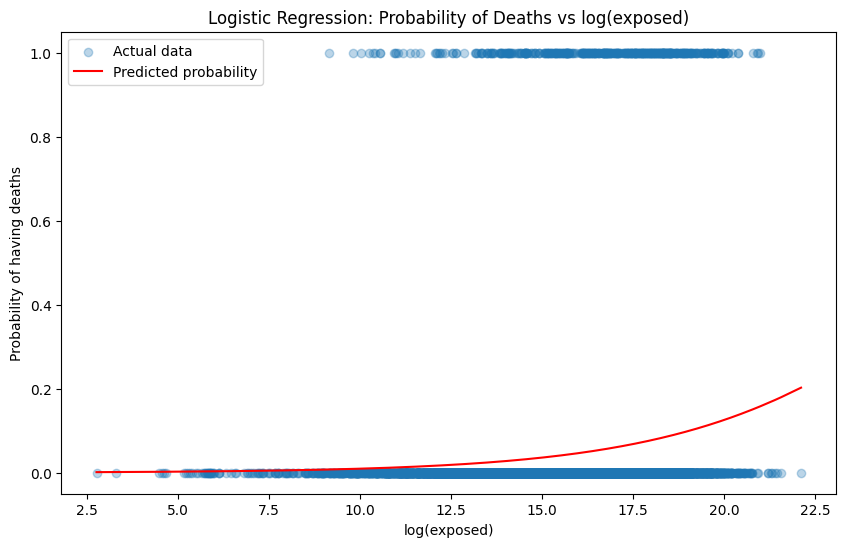

In [10]:
df['has_deaths'] = (df['deaths'] > 0).astype(int)
if 'log_exposed' not in df.columns:
    df['log_exposed'] = np.log(df['exposed'])

# Fit a logistic regression to predict has_deaths from log_exposed
import statsmodels.api as sm
model_data = df[np.isfinite(df['log_exposed'])].copy()
X = sm.add_constant(model_data['log_exposed'])
model = sm.Logit(model_data['has_deaths'], X)
result = model.fit()
print(result.summary())

# Plot predicted probabilities overlaid on observed points
model_data['pred_prob'] = result.predict(X)
order = np.argsort(model_data['log_exposed'].to_numpy())

plt.figure(figsize=(10, 6))
plt.scatter(model_data['log_exposed'], model_data['has_deaths'], alpha=0.3, label='Actual data')
plt.plot(
    model_data['log_exposed'].to_numpy()[order],
    model_data['pred_prob'].to_numpy()[order],
    color='red',
    label='Predicted probability'
 )
plt.xlabel('log(exposed)')
plt.ylabel('Probability of having deaths')
plt.title('Logistic Regression: Probability of Deaths vs log(exposed)')
plt.legend()
plt.show()

In [12]:
df.columns

Index(['deaths', 'exposed', 'wind_speed', 'sdi', 'basin', 'is_island',
       'storm_id', 'location_id', 'year', 'location_name',
       'path_to_top_parent', 'super_region_name', 'region_name', 'has_deaths',
       'log_exposed'],
      dtype='str')

In [18]:
# DIAGNOSTIC: Check for NaN values in the original data
numeric_covariates = ['log_exposed', 'wind_speed', 'sdi']
categorical_cols = ['basin', 'is_island']
all_cols = numeric_covariates + categorical_cols

print("NaN counts in original df:")
for col in all_cols:
    print(f"  {col}: {df[col].isna().sum()}")

print(f"\nTotal rows in df: {len(df)}")
print(f"Rows with any NaN in these columns: {df[all_cols].isna().any(axis=1).sum()}")
print(f"Rows with NO NaN in these columns: {(~df[all_cols].isna().any(axis=1)).sum()}")

sdi column info:
  dtype: float32
  non-null count: 3778
  null count: 5408
  value_counts (top 10):
sdi
0.323395    7
0.353706    7
0.595812    7
0.811807    7
0.817770    7
0.445400    6
0.674675    6
0.804150    6
0.374721    6
0.579457    6
Name: count, dtype: int64

Rows where sdi is NaN:
  Shape of NaN subset: (5408, 15)
  Columns in that subset: ['deaths', 'exposed', 'wind_speed', 'sdi', 'basin', 'is_island', 'storm_id', 'location_id', 'year', 'location_name', 'path_to_top_parent', 'super_region_name', 'region_name', 'has_deaths', 'log_exposed']

Sample of rows with NaN sdi:
    sdi basin       exposed  deaths
50  NaN    WP  2.764511e+06       0
51  NaN    WP  1.536187e+06       0
52  NaN    WP  1.907496e+06       0
53  NaN    WP  2.761487e+06       0
54  NaN    WP  1.953647e+04       0


In [22]:
nosdi = df[df['sdi'].isna()]
nosdi

,deaths,exposed,wind_speed,sdi,basin,is_island,storm_id,location_id,year,location_name,path_to_top_parent,super_region_name,region_name,has_deaths,log_exposed


In [15]:
df['has_deaths'] = (df['deaths'] > 0).astype(int)
if 'log_exposed' not in df.columns:
    df['log_exposed'] = np.log(df['exposed'])

# Fit a logistic regression to predict has_deaths from log_exposed and covariates
import statsmodels.api as sm

numeric_covariates = ['log_exposed', 'wind_speed', 'sdi']
categorical_cols = ['basin', 'is_island']

# Include numeric covariates, categorical columns, and outcome
model_data = df[numeric_covariates + categorical_cols + ['has_deaths']].copy()

# Encode categorical columns
model_data = pd.get_dummies(model_data, columns=categorical_cols, drop_first=True)

# Drop rows with missing values
model_data = model_data[np.all(np.isfinite(model_data[numeric_covariates]), axis=1)]

# Get all covariate columns (numeric + encoded categorical dummies)
covariate_cols = [c for c in model_data.columns if c not in ['has_deaths']]

X = sm.add_constant(model_data[covariate_cols])
model = sm.Logit(model_data['has_deaths'], X)
result = model.fit()
print(result.summary())

# Plot predicted probabilities overlaid on observed points
model_data['pred_prob'] = result.predict(X)
order = np.argsort(model_data['log_exposed'].to_numpy())

plt.figure(figsize=(10, 6))
plt.scatter(model_data['log_exposed'], model_data['has_deaths'], alpha=0.3, label='Actual data')
plt.plot(
    model_data['log_exposed'].to_numpy()[order],
    model_data['pred_prob'].to_numpy()[order],
    color='red',
    label='Predicted probability'
 )
plt.xlabel('log(exposed)')
plt.ylabel('Probability of having deaths')
plt.title('Logistic Regression: Probability of Deaths vs log(exposed)')
plt.legend()
plt.show()

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).